# PS2: Thực hiện phép tính so sánh sự chênh lệch về sản lượng tiêuthụ hàng hóa giữa các vùng địa giới khác nhau.

**Yêu cầu của đề:** Thực hiện phép tính so sánh sự chênh lệch về sản lượng tiêu thụ hàng hóa giữa các vùng địa giới khác nhau.

## 1. Cách làm

Sản lượng là **số sản phẩm**, không phải số đơn hay số tiền. Ví dụ: một đơn mua 7 sản phẩm và trả lại 2 thì sản lượng còn lại là 5.

Nhóm chọn cách tính: **Sản lượng tiêu thụ thuần = số lượng mua − số lượng trả lại**, áp dụng cho đơn đã giao (`delivered`) và đơn đã trả hàng (`returned`). Đây là cách tính nhóm lựa chọn để phản ánh số sản phẩm khách còn giữ.

- So sánh trực tiếp từng cặp Region.
- So sánh các City trong cùng Region với City có sản lượng cao nhất.
- So sánh các District trong cùng City với District có sản lượng cao nhất.
- Dùng toàn bộ thời gian trong dữ liệu. Sản lượng được gắn với địa chỉ và ngày đặt hàng gốc.

| Bảng | Cột cần dùng | Mục đích |
|---|---|---|
| orders | order_id, order_date, zip, order_status | Chọn trạng thái đơn và xác định địa bàn |
| order_items | order_id, product_id, quantity | Số sản phẩm mua trong đơn |
| returns | order_id, product_id, return_quantity | Số sản phẩm trả lại |
| geography | zip, region, city, district | Địa bàn tương ứng với ZIP |


## 2. Đọc dữ liệu

Chạy notebook từ thư mục `Problem/ProblemStatement2`. Chỉ đọc các cột cần dùng cho bài này.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.options.display.float_format = "{:,.2f}".format

orders = pd.read_csv("../../SilverData/orders_silver.csv",
                     usecols=["order_id", "order_date", "zip", "order_status"])
items = pd.read_csv("../../SilverData/order_items_silver.csv",
                    usecols=["order_id", "product_id", "quantity"])
returns = pd.read_csv("../../SilverData/returns_silver.csv",
                      usecols=["order_id", "product_id", "return_quantity"])
geography = pd.read_csv("../../SilverData/geography_silver.csv")
orders["order_date"] = pd.to_datetime(orders["order_date"])

print("Orders:", orders.shape)
print("Order items:", items.shape)
print("Returns:", returns.shape)
print("Geography:", geography.shape)
print("Thời gian:", orders["order_date"].min().date(), "đến", orders["order_date"].max().date())

Orders: (646945, 4)
Order items: (714669, 3)
Returns: (39939, 3)
Geography: (39948, 4)
Thời gian: 2012-07-04 đến 2022-12-31


## 3. Tính số lượng mua và trả của từng đơn

Một sản phẩm có thể xuất hiện ở nhiều dòng trong cùng đơn. Vì vậy, cộng theo **order_id + product_id** ở cả bảng mua và bảng trả trước khi ghép, tránh tính trùng.

Nếu số lượng trả lớn hơn số lượng mua thì phải kiểm tra dữ liệu, không tự sửa thành 0. Tiền hoàn có thể bao gồm khoản khác, nhưng số sản phẩm trả không thể vượt số đã mua trong đơn đó.

In [ ]:
assert items.notna().all().all(), "Bảng sản phẩm trong đơn có giá trị thiếu."
assert returns.notna().all().all(), "Bảng trả hàng có giá trị thiếu."
assert items["quantity"].gt(0).all(), "Có số lượng mua không hợp lệ."
assert returns["return_quantity"].gt(0).all(), "Có số lượng trả không hợp lệ."

item_quantity = (
    items.groupby(["order_id", "product_id"], as_index=False)
    .agg(purchased_quantity=("quantity", "sum"))
)
return_quantity = (
    returns.groupby(["order_id", "product_id"], as_index=False)
    .agg(returned_quantity=("return_quantity", "sum"))
)

quantity_detail = item_quantity.merge(
    return_quantity, on=["order_id", "product_id"],
    how="outer", validate="one_to_one", indicator=True
)
assert not quantity_detail["_merge"].eq("right_only").any(), "Có sản phẩm trả không tìm thấy trong đơn mua."
quantity_detail["returned_quantity"] = quantity_detail["returned_quantity"].fillna(0)
assert quantity_detail["returned_quantity"].le(quantity_detail["purchased_quantity"]).all(), "Có số lượng trả vượt số lượng mua."

quantity_by_order = (
    quantity_detail.groupby("order_id", as_index=False)
    .agg(
        purchased_quantity=("purchased_quantity", "sum"),
        returned_quantity=("returned_quantity", "sum")
    )
)

# Sau khi cộng, mỗi dòng là một đơn hàng.
assert quantity_by_order["order_id"].isin(orders["order_id"]).all(), "Có mã đơn không tồn tại trong orders."
df = orders.merge(quantity_by_order, on="order_id", how="left", validate="one_to_one")
df = df.merge(geography, on="zip", how="left", validate="many_to_one")
assert df[["purchased_quantity", "region", "city", "district", "order_date"]].notna().all().all(), "Có đơn thiếu số lượng hoặc địa bàn."
print("Số đơn trước và sau ghép:", len(orders), len(df))

Số đơn trước và sau ghép: 646945 646945


## 4. Chọn đơn dùng để tính sản lượng

- Dùng đơn `delivered` và `returned`.
- Không lấy đơn đang xử lý, đang giao hoặc đã hủy vào sản lượng tiêu thụ hoàn tất.
- Đơn `returned` không có dòng trả hàng được loại vì chưa biết khách trả bao nhiêu sản phẩm.
- Trong đơn có thông tin trả hàng, sản phẩm không có dòng trả được tính số lượng trả bằng 0. Một đơn có thể chỉ trả lại một phần.

Bảng dưới ghi rõ số đơn bị loại để người đọc biết phần dữ liệu chưa được tính.

In [ ]:
df_completed = df.loc[df["order_status"].isin(["delivered", "returned"])].copy()
missing_return = (
    df_completed["order_status"].eq("returned")
    & ~df_completed["order_id"].isin(returns["order_id"])
)
excluded_orders = df_completed.loc[missing_return].copy()
print("Đơn returned thiếu thông tin trả hàng bị loại:", len(excluded_orders))
print("Số sản phẩm mua của các đơn bị loại:", excluded_orders["purchased_quantity"].sum())
display(excluded_orders.groupby("region").agg(
    excluded_orders=("order_id", "nunique"),
    excluded_purchased_quantity=("purchased_quantity", "sum")
))

sales = df_completed.loc[~missing_return].copy()
sales["net_quantity"] = sales["purchased_quantity"] - sales["returned_quantity"]

print("Số đơn dùng phân tích:", len(sales))
print("Tổng số lượng mua: {:,.0f}".format(sales["purchased_quantity"].sum()))
print("Tổng số lượng trả: {:,.0f}".format(sales["returned_quantity"].sum()))
print("Sản lượng tiêu thụ thuần: {:,.0f}".format(sales["net_quantity"].sum()))

Đơn returned thiếu thông tin trả hàng bị loại: 80
Số sản phẩm mua của các đơn bị loại: 382


,excluded_orders,excluded_purchased_quantity
region,,
Central,26,121
East,31,139
West,23,122


Số đơn dùng phân tích: 552778
Tổng số lượng mua: 2,744,949
Tổng số lượng trả: 109,586
Sản lượng tiêu thụ thuần: 2,635,363


## 5. Sản lượng theo Region

Cộng sản lượng của các đơn thuộc cùng Region. Tỷ trọng (%) = sản lượng thuần của Region / sản lượng thuần toàn công ty × 100.

Xếp hạng theo sản lượng giảm dần; hạng 1 là vùng tiêu thụ nhiều nhất. `dense` cho các vùng bằng sản lượng cùng hạng.

In [ ]:
quantity_region = (
    sales.groupby("region", as_index=False)
    .agg(
        purchased_quantity=("purchased_quantity", "sum"),
        returned_quantity=("returned_quantity", "sum"),
        net_quantity=("net_quantity", "sum"),
        order_count=("order_id", "nunique")
    )
    .sort_values("net_quantity", ascending=False)
)
total_quantity = sales["net_quantity"].sum()
quantity_region["share_pct"] = quantity_region["net_quantity"] / total_quantity * 100
quantity_region["rank"] = quantity_region["net_quantity"].rank(method="dense", ascending=False)
display(quantity_region)

,region,purchased_quantity,returned_quantity,net_quantity,order_count,share_pct,rank
1,East,1232824,"48,986.00","1,183,838.00",251667,44.92,1.00
0,Central,773978,"30,553.00","743,425.00",157613,28.21,2.00
2,West,738147,"30,047.00","708,100.00",143498,26.87,3.00


### Chênh lệch giữa từng cặp Region

Ghép bảng Region với chính nó để tạo các cặp A và B; chỉ giữ mỗi cặp một lần.

- `difference_quantity` = sản lượng A − sản lượng B.
- `difference_pct` = (sản lượng A − sản lượng B) / sản lượng B × 100. **B là vùng làm mốc so sánh.**
- Kết quả dương: A nhiều hơn B; âm: A ít hơn B; bằng 0: hai vùng bằng nhau.

Ví dụ: A có 120 sản phẩm, B có 100 thì A nhiều hơn B 20 sản phẩm, tương đương 20% so với B.

In [ ]:
region_a = quantity_region[["region", "net_quantity"]].rename(
    columns={"region": "region_a", "net_quantity": "quantity_a"}
)
region_b = quantity_region[["region", "net_quantity"]].rename(
    columns={"region": "region_b", "net_quantity": "quantity_b"}
)
region_comparison = region_a.merge(region_b, how="cross")
# Dùng thứ tự tên để bỏ cặp trùng và cặp so sánh một vùng với chính nó.
region_comparison = region_comparison.loc[
    region_comparison["region_a"] < region_comparison["region_b"]
].copy()
region_comparison["difference_quantity"] = (
    region_comparison["quantity_a"] - region_comparison["quantity_b"]
)
region_comparison["difference_pct"] = (
    region_comparison["difference_quantity"]
    / region_comparison["quantity_b"].replace(0, float("nan")) * 100
)
display(region_comparison)

,region_a,quantity_a,region_b,quantity_b,difference_quantity,difference_pct
2,East,"1,183,838.00",West,"708,100.00","475,738.00",67.19
3,Central,"743,425.00",East,"1,183,838.00","-440,413.00",-37.20
5,Central,"743,425.00",West,"708,100.00","35,325.00",4.99


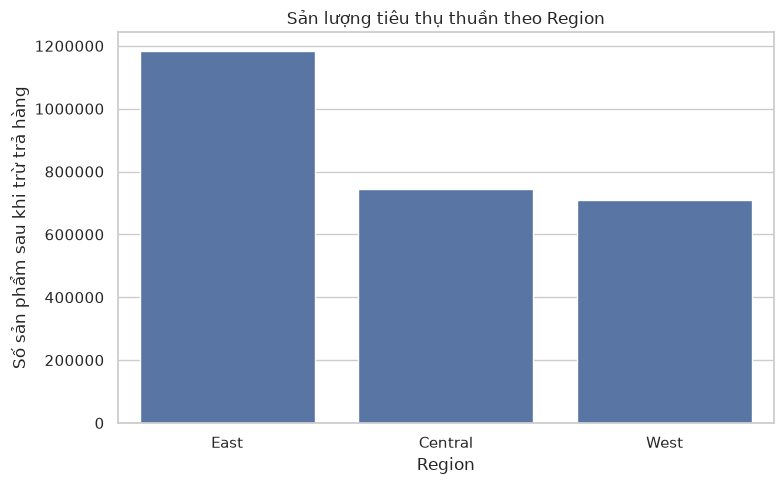

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(data=quantity_region, x="region", y="net_quantity")
plt.title("Sản lượng tiêu thụ thuần theo Region")
plt.xlabel("Region")
plt.ylabel("Số sản phẩm sau khi trừ trả hàng")
plt.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.show()

## 6. So sánh City trong cùng Region

Nhóm theo cả Region và City để không gộp các địa bàn trùng tên.

- `rank_in_region`: thứ hạng City trong Region.
- `gap_to_top`: City đó ít hơn City dẫn đầu cùng Region bao nhiêu sản phẩm.
- `gap_to_top_pct`: chênh lệch trên chia cho sản lượng City dẫn đầu × 100.

City dẫn đầu có chênh lệch bằng 0. Bảng giữ tất cả City; biểu đồ chỉ hiển thị 15 City có sản lượng cao nhất toàn công ty.

In [ ]:
quantity_city = (
    sales.groupby(["region", "city"], as_index=False)
    .agg(net_quantity=("net_quantity", "sum"))
)
quantity_city["rank_in_region"] = (
    quantity_city.groupby("region")["net_quantity"].rank(method="dense", ascending=False)
)
quantity_city["top_quantity_in_region"] = (
    quantity_city.groupby("region")["net_quantity"].transform("max")
)
quantity_city["gap_to_top"] = quantity_city["top_quantity_in_region"] - quantity_city["net_quantity"]
quantity_city["gap_to_top_pct"] = (
    quantity_city["gap_to_top"] / quantity_city["top_quantity_in_region"].replace(0, float("nan")) * 100
)
quantity_city = quantity_city.sort_values(["region", "rank_in_region"])
display(quantity_city)

,region,city,net_quantity,rank_in_region,top_quantity_in_region,gap_to_top,gap_to_top_pct
4,Central,Kon Tum,"69,107.00",1.00,"69,107.00",0.00,0.00
3,Central,Hue,"65,864.00",2.00,"69,107.00","3,243.00",4.69
7,Central,Phan Thiet,"65,480.00",3.00,"69,107.00","3,627.00",5.25
8,Central,Quang Ngai,"65,218.00",4.00,"69,107.00","3,889.00",5.63
1,Central,Dong Hoi,"62,787.00",5.00,"69,107.00","6,320.00",9.15
6,Central,Phan Rang-Thap Cham,"62,643.00",6.00,"69,107.00","6,464.00",9.35
9,Central,Quy Nhon,"62,012.00",7.00,"69,107.00","7,095.00",10.27
2,Central,Hoi An,"61,708.00",8.00,"69,107.00","7,399.00",10.71
5,Central,Nha Trang,"59,028.00",9.00,"69,107.00","10,079.00",14.58
10,Central,Tam Ky,"58,073.00",10.00,"69,107.00","11,034.00",15.97


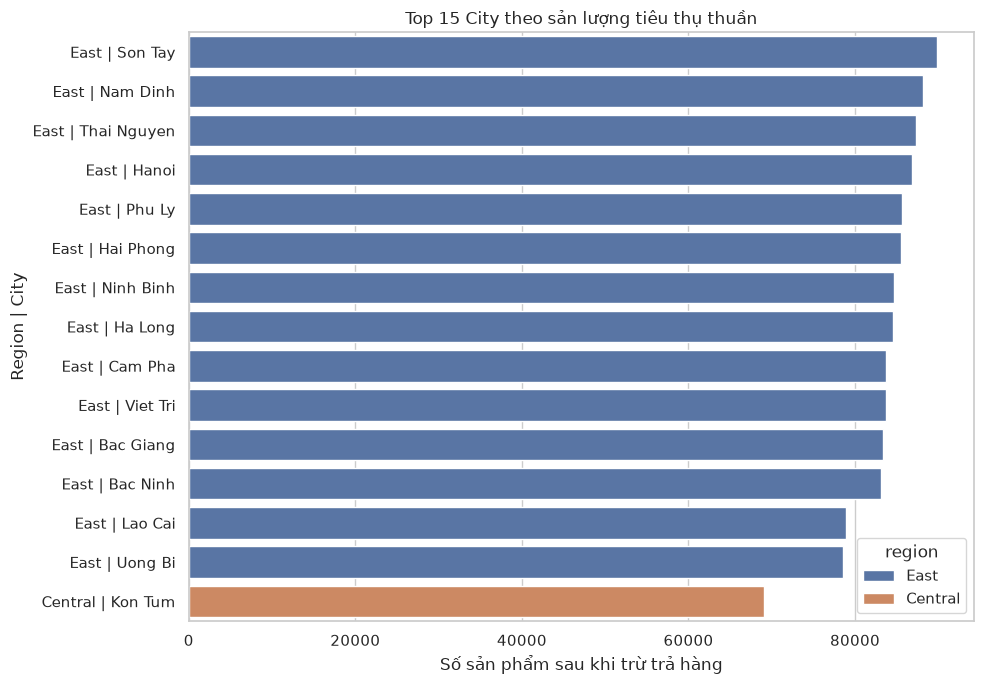

In [ ]:
top_city = quantity_city.nlargest(15, "net_quantity").copy()
top_city["label"] = top_city["region"] + " | " + top_city["city"]
plt.figure(figsize=(10, 7))
sns.barplot(data=top_city, x="net_quantity", y="label", hue="region", dodge=False)
plt.title("Top 15 City theo sản lượng tiêu thụ thuần")
plt.xlabel("Số sản phẩm sau khi trừ trả hàng")
plt.ylabel("Region | City")
plt.tight_layout()
plt.show()

## 7. So sánh District trong cùng City

Một District được xác định bằng **Region + City + District** vì tên District có thể trùng nhau.

Cách tính giống phần City, nhưng mốc so sánh là District dẫn đầu trong cùng City. Bảng hiển thị 20 dòng đầu; `quantity_district` vẫn giữ đủ các District.

In [ ]:
quantity_district = (
    sales.groupby(["region", "city", "district"], as_index=False)
    .agg(net_quantity=("net_quantity", "sum"))
)
quantity_district["rank_in_city"] = (
    quantity_district.groupby(["region", "city"])["net_quantity"].rank(method="dense", ascending=False)
)
quantity_district["top_quantity_in_city"] = (
    quantity_district.groupby(["region", "city"])["net_quantity"].transform("max")
)
quantity_district["gap_to_top"] = quantity_district["top_quantity_in_city"] - quantity_district["net_quantity"]
quantity_district["gap_to_top_pct"] = (
    quantity_district["gap_to_top"] / quantity_district["top_quantity_in_city"].replace(0, float("nan")) * 100
)
quantity_district = quantity_district.sort_values(["region", "city", "rank_in_city"])
display(quantity_district.head(20))
print("Tổng số District:", len(quantity_district))

,region,city,district,net_quantity,rank_in_city,top_quantity_in_city,gap_to_top,gap_to_top_pct
5,Central,Da Nang,District #25,"7,749.00",1.00,"7,749.00",0.00,0.00
1,Central,Da Nang,District #21,"6,340.00",2.00,"7,749.00","1,409.00",18.18
3,Central,Da Nang,District #23,"6,090.00",3.00,"7,749.00","1,659.00",21.41
8,Central,Da Nang,District #28,"5,479.00",4.00,"7,749.00","2,270.00",29.29
2,Central,Da Nang,District #22,"5,080.00",5.00,"7,749.00","2,669.00",34.44
0,Central,Da Nang,District #20,"4,954.00",6.00,"7,749.00","2,795.00",36.07
4,Central,Da Nang,District #24,"4,249.00",7.00,"7,749.00","3,500.00",45.17
10,Central,Da Nang,District #30,"4,000.00",8.00,"7,749.00","3,749.00",48.38
11,Central,Da Nang,District #31,"3,792.00",9.00,"7,749.00","3,957.00",51.06
12,Central,Da Nang,District #32,"3,166.00",10.00,"7,749.00","4,583.00",59.14


Tổng số District: 534


## 8. Nhận xét từ kết quả

Phần dưới cho biết vùng dẫn đầu, vùng có sản lượng thấp nhất, chênh lệch giữa chúng và chênh lệch từng cặp Region. Các nhận xét dùng số liệu đã tính ở trên.

In [ ]:
highest = quantity_region.iloc[0]
lowest = quantity_region.iloc[-1]
gap = highest["net_quantity"] - lowest["net_quantity"]

print("Region tiêu thụ nhiều nhất: {} — {:,.0f} sản phẩm, chiếm {:.2f}%.".format(
    highest["region"], highest["net_quantity"], highest["share_pct"]
))
print("Region tiêu thụ ít nhất: {} — {:,.0f} sản phẩm, chiếm {:.2f}%.".format(
    lowest["region"], lowest["net_quantity"], lowest["share_pct"]
))
print("Chênh lệch cao nhất và thấp nhất: {:,.0f} sản phẩm.".format(gap))

for _, row in region_comparison.iterrows():
    direction = "nhiều hơn" if row["difference_quantity"] >= 0 else "ít hơn"
    print("{} {} {} {:,.0f} sản phẩm ({:.2f}% so với {}).".format(
        row["region_a"], direction, row["region_b"],
        abs(row["difference_quantity"]), abs(row["difference_pct"]), row["region_b"]
    ))

city_leaders = quantity_city.loc[quantity_city["rank_in_region"] == 1]
print("City dẫn đầu của mỗi Region:")
display(city_leaders[["region", "city", "net_quantity"]])

print("District dẫn đầu của từng City:")
display(quantity_district.loc[
    quantity_district["rank_in_city"] == 1,
    ["region", "city", "district", "net_quantity"]
])

Region tiêu thụ nhiều nhất: East — 1,183,838 sản phẩm, chiếm 44.92%.
Region tiêu thụ ít nhất: West — 708,100 sản phẩm, chiếm 26.87%.
Chênh lệch cao nhất và thấp nhất: 475,738 sản phẩm.
East nhiều hơn West 475,738 sản phẩm (67.19% so với West).
Central ít hơn East 440,413 sản phẩm (37.20% so với East).
Central nhiều hơn West 35,325 sản phẩm (4.99% so với West).
City dẫn đầu của mỗi Region:


,region,city,net_quantity
4,Central,Kon Tum,"69,107.00"
22,East,Son Tay,"89,792.00"
36,West,Pleiku,"53,961.00"


District dẫn đầu của từng City:


,region,city,district,net_quantity
5,Central,Da Nang,District #25,"7,749.00"
16,Central,Dong Hoi,District #23,"8,970.00"
26,Central,Hoi An,District #20,"7,516.00"
42,Central,Hue,District #23,"8,494.00"
54,Central,Kon Tum,District #22,"9,696.00"
68,Central,Nha Trang,District #23,"7,581.00"
89,Central,Phan Rang-Thap Cham,District #31,"6,959.00"
102,Central,Phan Thiet,District #31,"8,164.00"
108,Central,Quang Ngai,District #24,"8,179.00"
120,Central,Quy Nhon,District #23,"8,955.00"


## 9. Kết luận và lưu ý

Bài đã tính sản lượng thuần và chênh lệch giữa các Region, giữa City trong cùng Region và giữa District trong cùng City. Số liệu giúp nhận biết nơi tiêu thụ nhiều hoặc ít để xem xét nhu cầu phân phối hàng hóa.

- Vùng có sản lượng cao chưa chắc có doanh thu hoặc lợi nhuận cao vì các sản phẩm có giá và chi phí khác nhau.
- Vùng lớn hoặc nhiều khách hàng có thể tiêu thụ nhiều hơn. Chưa thể chỉ từ tổng sản lượng kết luận chiến lược của vùng đó tốt hơn.
- Một đơn returned có thể chỉ trả một phần sản phẩm, nên không loại toàn bộ sản lượng của các đơn này.
- Kết quả không bao gồm đơn returned thiếu dữ liệu trả hàng; số đơn và lượng mua bị loại đã được nêu ở phần chuẩn bị.
- Bài cộng số sản phẩm thuộc nhiều loại. Nếu cần lập kế hoạch cho từng mặt hàng, nên phân tích tiếp theo sản phẩm hoặc danh mục.
- Đề xuất phân phối thực tế cần xem thêm nhu cầu gần đây, tồn kho và khả năng vận chuyển; tổng sản lượng cả giai đoạn không phải dự báo cho kỳ tiếp theo.